In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("Flight_Fare_Data.csv")

## Data Overview

Basic exploration is performed to understand the dataset structure, data types, and summary statistics.
This helps in identifying missing values and feature characteristics.

In [9]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR ? DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU ? IXR ? BBI ? BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL ? LKO ? BOM ? COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU ? NAG ? BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR ? NAG ? DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [10]:
df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU ? BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU ? BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR ? DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR ? DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL ? GOI ? BOM ? COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [12]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [13]:
df.shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.columns

Rows: 10683
Columns: 11


Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

## Handling Missing Values

Missing values are handled to ensure data quality. 
This step prevents errors during model training and improves model performance.

In [14]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [15]:
df.dropna(inplace=True)

In [16]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [17]:
df.dtypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

In [18]:
df.Airline.value_counts()

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1751
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

In [19]:
df['Total_Stops'].isnull().sum()

np.int64(0)

In [20]:
df['Total_Stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

## DATA PREPROCESSING

In [21]:
df['Total_Stops'] = df['Total_Stops'].astype(str)
df['Total_Stops'] = df['Total_Stops'].map(lambda x: 0 if x=='non-stop' else int(x.split()[0]))

In [22]:
df['Total_Stops'].head()

0    0
1    2
2    2
3    1
4    1
Name: Total_Stops, dtype: int64

In [23]:
df['Total_Stops'].unique()

array([0, 2, 1, 3, 4])

In [24]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR ? DEL,22:20,01:10 22 Mar,2h 50m,0,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU ? IXR ? BBI ? BLR,05:50,13:15,7h 25m,2,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL ? LKO ? BOM ? COK,09:25,04:25 10 Jun,19h,2,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU ? NAG ? BLR,18:05,23:30,5h 25m,1,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR ? NAG ? DEL,16:50,21:35,4h 45m,1,No info,13302


### The 'Total_Stops' column was transformed from categorical text values into numerical format by mapping the number of stops (e.g., non-stop = 0, 1 stop = 1, etc.), making it suitable for machine learning models.

## Feature Engineering (Date, Time, Duration)

New features such as journey day, month, departure time, and duration are extracted 
from existing columns to improve the model’s predictive capability.

In [25]:
df['Duration'].head()

0    2h 50m
1    7h 25m
2       19h
3    5h 25m
4    4h 45m
Name: Duration, dtype: object

In [26]:
df['Duration'] = df['Duration'].fillna('0h 0m')
#Extracting Hours
df['Duration_hour'] = df['Duration'].str.extract('(\d+)h')
df['Duration_hour'] = df['Duration_hour'].fillna(0).astype(int)
#Extracting Minutes
df['Duration_min'] = df['Duration'].str.extract('(\d+)m')
df['Duration_min'] = df['Duration_min'].fillna(0).astype(int)
#Now we can drop Duration as it is of no use 
df.drop('Duration', axis=1, inplace=True)

df[['Duration_hour', 'Duration_min']].head()

,Duration_hour,Duration_min
0,2,50
1,7,25
2,19,0
3,5,25
4,4,45


In [27]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Total_Stops,Additional_Info,Price,Duration_hour,Duration_min
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR ? DEL,22:20,01:10 22 Mar,0,No info,3897,2,50
1,Air India,1/05/2019,Kolkata,Banglore,CCU ? IXR ? BBI ? BLR,05:50,13:15,2,No info,7662,7,25
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL ? LKO ? BOM ? COK,09:25,04:25 10 Jun,2,No info,13882,19,0
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU ? NAG ? BLR,18:05,23:30,1,No info,6218,5,25
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR ? NAG ? DEL,16:50,21:35,1,No info,13302,4,45


In [29]:
df['Route'].head()

0                BLR ? DEL
1    CCU ? IXR ? BBI ? BLR
2    DEL ? LKO ? BOM ? COK
3          CCU ? NAG ? BLR
4          BLR ? NAG ? DEL
Name: Route, dtype: object

In [30]:
df['Route'] = df['Route'].fillna('')

In [32]:
# Clean Route column (optional formatting)
df['Route'] = df['Route'].str.replace(' ', '')
df['Route'] = df['Route'].str.replace('?', ' → ', regex=False)


In [33]:
# Remove Stops_Count column if created
if 'Stops_Count' in df.columns:
    df.drop('Stops_Count', axis=1, inplace=True)

In [34]:
df[['Route']].head()

,Route
0,BLR→DEL
1,CCU→IXR→BBI→BLR
2,DEL→LKO→BOM→COK
3,CCU→NAG→BLR
4,BLR→NAG→DEL


In [35]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Total_Stops,Additional_Info,Price,Duration_hour,Duration_min
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR→DEL,22:20,01:10 22 Mar,0,No info,3897,2,50
1,Air India,1/05/2019,Kolkata,Banglore,CCU→IXR→BBI→BLR,05:50,13:15,2,No info,7662,7,25
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL→LKO→BOM→COK,09:25,04:25 10 Jun,2,No info,13882,19,0
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU→NAG→BLR,18:05,23:30,1,No info,6218,5,25
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR→NAG→DEL,16:50,21:35,1,No info,13302,4,45


In [36]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Total_Stops', 'Additional_Info', 'Price',
       'Duration_hour', 'Duration_min'],
      dtype='object')

In [37]:
df['Dep_Hour'] = pd.to_datetime(df['Dep_Time'], format='%H:%M').dt.hour
df['Dep_Min'] = pd.to_datetime(df['Dep_Time'], format='%H:%M').dt.minute

df['Arrival_Time'] = df['Arrival_Time'].str.split(' ').str[0]

df['Arrival_Hour'] = pd.to_datetime(df['Arrival_Time'], format='%H:%M').dt.hour
df['Arrival_Min'] = pd.to_datetime(df['Arrival_Time'], format='%H:%M').dt.minute

In [38]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Total_Stops,Additional_Info,Price,Duration_hour,Duration_min,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR→DEL,22:20,01:10,0,No info,3897,2,50,22,20,1,10
1,Air India,1/05/2019,Kolkata,Banglore,CCU→IXR→BBI→BLR,05:50,13:15,2,No info,7662,7,25,5,50,13,15
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL→LKO→BOM→COK,09:25,04:25,2,No info,13882,19,0,9,25,4,25
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU→NAG→BLR,18:05,23:30,1,No info,6218,5,25,18,5,23,30
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR→NAG→DEL,16:50,21:35,1,No info,13302,4,45,16,50,21,35


## Drop Unnecessary Columns

Removing Unnecessary Features

Irrelevant columns are removed to reduce noise and improve model efficiency.

In [39]:
df = df.drop(['Dep_Time', 'Arrival_Time'], axis=1, errors='ignore')

In [40]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Total_Stops', 'Additional_Info', 'Price', 'Duration_hour',
       'Duration_min', 'Dep_Hour', 'Dep_Min', 'Arrival_Hour', 'Arrival_Min'],
      dtype='object')

In [41]:
df['Duration_total'] = df['Duration_hour'] * 60 + df['Duration_min']

df = df.drop(['Duration_hour', 'Duration_min'], axis=1)

In [42]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Total_Stops', 'Additional_Info', 'Price', 'Dep_Hour', 'Dep_Min',
       'Arrival_Hour', 'Arrival_Min', 'Duration_total'],
      dtype='object')

In [43]:
df = pd.get_dummies(
    df,
    columns=['Source', 'Destination'],
    drop_first=True
)

In [44]:
df['Airline'] = df.groupby('Airline')['Price'].transform('mean')

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Airline                10682 non-null  float64
 1   Date_of_Journey        10682 non-null  object 
 2   Route                  10682 non-null  object 
 3   Total_Stops            10682 non-null  int64  
 4   Additional_Info        10682 non-null  object 
 5   Price                  10682 non-null  int64  
 6   Dep_Hour               10682 non-null  int32  
 7   Dep_Min                10682 non-null  int32  
 8   Arrival_Hour           10682 non-null  int32  
 9   Arrival_Min            10682 non-null  int32  
 10  Duration_total         10682 non-null  int64  
 11  Source_Chennai         10682 non-null  bool   
 12  Source_Delhi           10682 non-null  bool   
 13  Source_Kolkata         10682 non-null  bool   
 14  Source_Mumbai          10682 non-null  bool   
 15  Destina

In [46]:
df['Journey_Day'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y').dt.day
df['Journey_Month'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y').dt.month

df = df.drop('Date_of_Journey', axis=1)

In [47]:
df = df.drop(['Route', 'Additional_Info'], axis=1, errors='ignore')

In [48]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [49]:
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Airline                10682 non-null  float64
 1   Total_Stops            10682 non-null  int64  
 2   Price                  10682 non-null  int64  
 3   Dep_Hour               10682 non-null  int32  
 4   Dep_Min                10682 non-null  int32  
 5   Arrival_Hour           10682 non-null  int32  
 6   Arrival_Min            10682 non-null  int32  
 7   Duration_total         10682 non-null  int64  
 8   Source_Chennai         10682 non-null  int64  
 9   Source_Delhi           10682 non-null  int64  
 10  Source_Kolkata         10682 non-null  int64  
 11  Source_Mumbai          10682 non-null  int64  
 12  Destination_Cochin     10682 non-null  int64  
 13  Destination_Delhi      10682 non-null  int64  
 14  Destination_Hyderabad  10682 non-null  int64  
 15  Destina

## Encoding Categorical Variables

Categorical features such as airline, source, and destination are converted into numerical format 
using encoding techniques so that they can be used by machine learning models.

In [50]:
df.head()

,Airline,Total_Stops,Price,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_total,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi,Journey_Day,Journey_Month
0,5673.682903,0,3897,22,20,1,10,170,0,0,0,0,0,0,0,0,1,24,3
1,9612.427756,2,7662,5,50,13,15,445,0,0,1,0,0,0,0,0,0,1,5
2,11643.923357,2,13882,9,25,4,25,1140,0,1,0,0,1,0,0,0,0,9,6
3,5673.682903,1,6218,18,5,23,30,325,0,0,1,0,0,0,0,0,0,12,5
4,5673.682903,1,13302,16,50,21,35,285,0,0,0,0,0,0,0,0,1,1,3


In [51]:
df

,Airline,Total_Stops,Price,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_total,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi,Journey_Day,Journey_Month
0,5673.682903,0,3897,22,20,1,10,170,0,0,0,0,0,0,0,0,1,24,3
1,9612.427756,2,7662,5,50,13,15,445,0,0,1,0,0,0,0,0,0,1,5
2,11643.923357,2,13882,9,25,4,25,1140,0,1,0,0,1,0,0,0,0,9,6
3,5673.682903,1,6218,18,5,23,30,325,0,0,1,0,0,0,0,0,0,12,5
4,5673.682903,1,13302,16,50,21,35,285,0,0,0,0,0,0,0,0,1,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,5590.260188,0,4107,19,55,22,25,150,0,0,1,0,0,0,0,0,0,9,4
10679,9612.427756,0,4145,20,45,23,20,155,0,0,1,0,0,0,0,0,0,27,4
10680,11643.923357,0,7229,8,20,11,20,180,0,0,0,0,0,1,0,0,0,27,4
10681,7796.348643,0,12648,11,30,14,10,160,0,0,0,0,0,0,0,0,1,1,3


## Feature Scaling

In [53]:
X = df.drop('Price', axis=1)
y = df['Price']

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Model Building - Linear Regression

A Linear Regression model is used as a baseline to understand the relationship between features and flight prices.

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [59]:
#Model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Prediction
y_pred = lr.predict(X_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 2040.806044876123
RMSE: 2921.4831346180663
R2 Score: 0.6041628137157926


## Model Building - Random Forest

A Random Forest Regressor is applied to capture complex and non-linear relationships in the data. 
This model generally provides better accuracy compared to Linear Regression.

In [60]:

from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)

# Train
rf.fit(X_train, y_train)

# Prediction
y_pred_rf = rf.predict(X_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred_rf))

rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("RMSE:", rmse)

print("R2 Score:", r2_score(y_test, y_pred_rf))


MAE: 1170.53864476709
RMSE: 1957.8193455746377
R2 Score: 0.8222313988851288


In [61]:
# Get feature importance
importance = rf.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort values
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Show top features
print(feature_importance.head(10))

                  Feature  Importance
6          Duration_total    0.468857
0                 Airline    0.176767
16            Journey_Day    0.124057
17          Journey_Month    0.065400
4            Arrival_Hour    0.036642
2                Dep_Hour    0.029848
3                 Dep_Min    0.023920
5             Arrival_Min    0.021327
1             Total_Stops    0.020599
15  Destination_New Delhi    0.013122


Flight price is mainly influenced by duration, airline, and travel date rather than minor factors like minutes or specific destinations

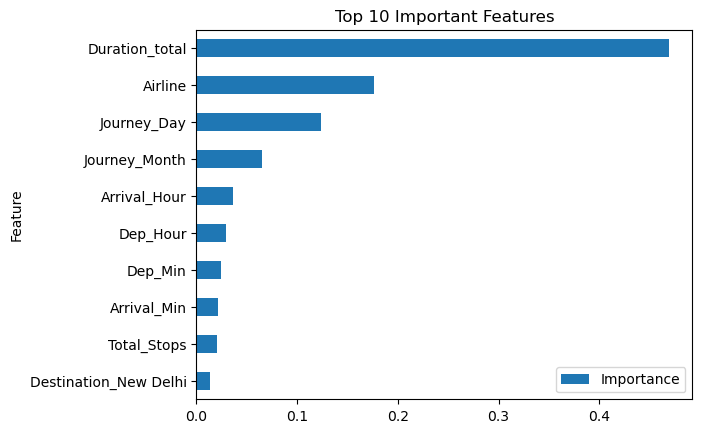

In [70]:
import matplotlib.pyplot as plt

# Plot top 10 features
feature_importance.head(10).plot(
    x='Feature', y='Importance', kind='barh'
)

plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

## Hyperparameter Tuning

RandomizedSearchCV is used to find the best combination of parameters 
to improve model performance.

In [64]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Parameter grid
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Base model
rf = RandomForestRegressor(random_state=42)

# Random search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=10,          # number of combinations
    cv=3,               # cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Train
random_search.fit(X_train, y_train)

# Best model
best_rf = random_search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [65]:
print("Best Parameters:", random_search.best_params_)

Best Parameters: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 30}


In [66]:
y_pred_tuned = best_rf.predict(X_test)

In [67]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred_tuned))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tuned)))
print("R2 Score:", r2_score(y_test, y_pred_tuned))

MAE: 1124.6111876360212
RMSE: 1829.7133838163998
R2 Score: 0.8447341470319155


Initial performance improved significantly after hyperparameter tuning using RandomizedSearchCV. The final model achieved an R² score of 0.84 with reduced MAE and RMSE, indicating strong predictive performance

**Save Model & Feature Column**

The trained model is saved using pickle so that it can be reused without retraining.
Feature columns are also saved to ensure consistency during prediction.

In [74]:
import pickle

# Save model
pickle.dump(best_rf, open('flight_price_model.pkl', 'wb'))

# Save columns 
pickle.dump(X.columns, open('model_columns.pkl', 'wb'))

**Load Model & Column**

The saved model and feature columns are loaded for making predictions on new data.

In [76]:
# Load model
model = pickle.load(open('flight_price_model.pkl', 'rb'))

# Load columns
model_columns = pickle.load(open('model_columns.pkl', 'rb'))

**Make Prediction on New Data**

New input data is processed and passed to the trained model to predict flight price.

In [84]:
new_data = {
    'Airline': 'IndiGo',
    'Date_of_Journey': '24/03/2019',
    'Source': 'Delhi',
    'Destination': 'Cochin',
    'Route': 'DEL → BLR → COK',
    'Total_Stops': 1,
    'Additional_Info': 'No info',
    'Dep_Hour': 10,
    'Dep_Min': 30,
    'Arrival_Hour': 12,
    'Arrival_Min': 45,
    'Duration_total': 120
}
input_df = pd.DataFrame([new_data])
input_encoded = pd.get_dummies(input_df)
input_encoded = input_encoded.reindex(columns=model_columns, fill_value=0)
prediction = model.predict(input_encoded.values)

print("Predicted Price:₹", round(prediction[0], 2))

Predicted Price:₹ 8820.25


### The Flight Price Prediction model was successfully developed using machine learning techniques. After data preprocessing, feature engineering, and model building, the Random Forest model provided the best performance.Hyperparameter tuning further improved the model accuracy, achieving an R² score of 0.84 with reduced error values.Finally, the model was used to predict flight prices on new data. For the given input, the predicted flight price is approximately ₹8820.